# Ebola SEIHFR-V Model — Democratic Republic of Congo

This notebook demonstrates the **SEIHFR-V** (Susceptible – Exposed – Infectious – Hospitalized – Funeral – Recovered – Vaccinated) compartmental model for Ebola epidemic dynamics.

The model incorporates Ebola-specific transmission pathways (community, hospital, and funeral/burial), clinical outcomes, and vaccination effects using the rVSV-ZEBOV (Ervebo) vaccine deployed via ring vaccination.

**Reference:** Coelho, F. C. (2026). *Ebola Epidemic Mathematical Model — Democratic Republic of Congo.* EpidBot Analysis Report. [doi:10.5281/zenodo.20634292](https://doi.org/10.5281/zenodo.20634292)

In [1]:
from IPython.display import Markdown as md
import numpy as np
import matplotlib.pyplot as plt

from epimodels.continuous import models as CM

## Model Structure

The model uses 7 dynamic compartments plus 2 cumulative tracking variables:

| Compartment | Description |
|-------------|-------------|
| **S** | Susceptible individuals |
| **E** | Exposed / incubating (not yet infectious, mean 9 days) |
| **I** | Infectious in community (symptomatic, not hospitalized, mean 5 days) |
| **H** | Hospitalized (reduced infectivity by factor $\phi_H$, mean 7 days) |
| **R** | Recovered and immune |
| **V** | Vaccinated (with efficacy $\varepsilon = 97.5\%$) |
| **D** | Infectious deceased (during burial period, mean 2 days) |
| **Cc** | Cumulative cases (tracking) |
| **Cd** | Cumulative deaths (tracking) |

Three transmission pathways:
1. **Community** — from infectious individuals ($I$)
2. **Hospital** — from hospitalized patients ($H$), reduced by factor $\phi_H$
3. **Funeral/burial** — from deceased individuals ($D$), weighted by $\theta$

In [2]:
model = CM.EbolaSEIHFRV()
md(str(model))


# Model: SEIHFR-V

```mermaid
flowchart LR

S(Susceptible) -->|$$\Lambda$$| E(Exposed)
E -->|$$\sigma$$| I(Infectious)
I -->|$$f_H$$| H(Hospitalized)
I -->|$$\gamma_I$$| R(Recovered)
H -->|$$\gamma_H$$| R
I -->|$$\rho \cdot CFR$$| D(Deceased)
H -->|$$\mu_H$$| D
D -->|$$\mu_D$$| B(Burial)
S -->|$$\nu \cdot \epsilon$$| V(Vaccinated)

```


## Base Parameters

These values are drawn from WHO fact sheets, CDC outbreak reports, and published literature as summarized in the technical report.

In [3]:
# Common parameters shared across scenarios (DRC health zone, N = 500,000)
N = 500_000

base_params = {
    'beta':    0.40,       # Transmission rate (day^-1)
    'sigma':   1 / 9,      # Incubation rate (mean 9 days)
    'gammaI':  1 / 5,      # Community infectious rate (mean 5 days)
    'gammaH':  1 / 7,      # Hospital discharge rate (mean 7 days)
    'muD':     1 / 2,      # Burial rate (mean 2 days)
    'theta':   0.50,       # Funeral transmission weight
    'phiH':    0.10,       # Hospital transmission factor
    'fH':      0.60,       # Hospitalization rate
    'CFR':     0.50,       # Case fatality rate
    'rho':     0.70,       # Relative community CFR factor
    'epsilon': 0.975,      # Vaccine efficacy
}

# Initial conditions: 10 initial infectious in a population of 500,000
inits = [N - 10, 0, 10, 0, 0, 0, 0, 0, 0]
trange = [0, 365]

## Scenario 1: No Intervention

No vaccination, no improved hospitalization, no safe burials. This represents the worst-case baseline.

R0 = 2.271
Components: {'community': 2.0, 'hospital': 0.028000000000000008, 'funeral': 0.24320000000000006, 'total': 2.2712}
Total cases: 422,460
Total deaths: 126,741


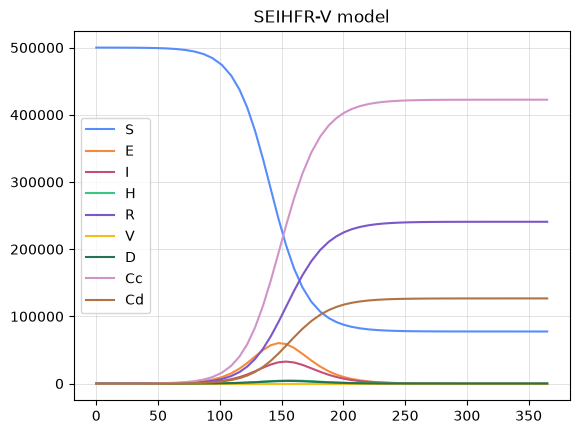

In [4]:
params_no_intervention = {**base_params, 'nu': 0.0, 'fH': 0.20, 'theta': 0.80, 'phiH': 0.05}

model_no = CM.EbolaSEIHFRV()
model_no(inits, trange, N, params_no_intervention)

print(f"R0 = {model_no.R0:.3f}")
print(f"Components: {model_no.R0_components}")
print(f"Total cases: {model_no.traces['Cc'][-1]:,.0f}")
print(f"Total deaths: {model_no.traces['Cd'][-1]:,.0f}")

model_no.plot_traces()

## Scenario 2: Current DRC Response

Moderate ring vaccination + infection prevention & control (IPC) + safe burials. This reflects a realistic response scenario.

R0 = 2.221
Total cases: 13,404
Total deaths: 3,890


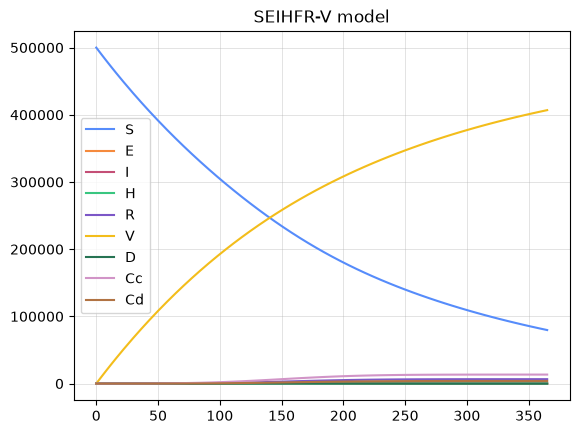

In [5]:
params_drc = {**base_params, 'nu': 0.005, 'fH': 0.40, 'theta': 0.40, 'phiH': 0.08}

model_drc = CM.EbolaSEIHFRV()
model_drc(inits, trange, N, params_drc)

print(f"R0 = {model_drc.R0:.3f}")
print(f"Total cases: {model_drc.traces['Cc'][-1]:,.0f}")
print(f"Total deaths: {model_drc.traces['Cd'][-1]:,.0f}")

model_drc.plot_traces()

## Scenario 3: Enhanced Vaccination

Ring vaccination at 1.5%/day, combined with strong hospitalization (80%) and safe burials. This achieves near-elimination.

R0 = 2.299
Total cases: 366
Total deaths: 147


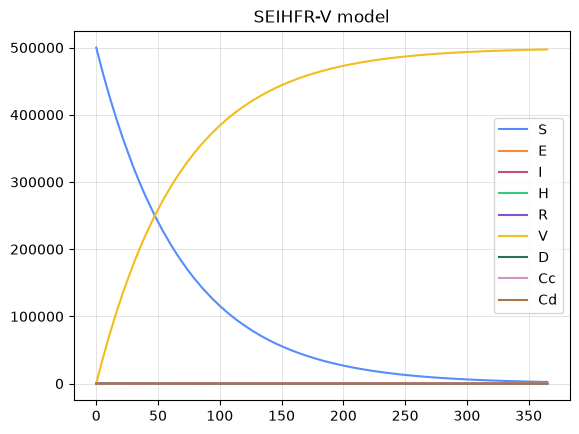

In [6]:
params_enhanced = {**base_params, 'nu': 0.015, 'fH': 0.80, 'theta': 0.20, 'phiH': 0.10}

model_enh = CM.EbolaSEIHFRV()
model_enh(inits, trange, N, params_enhanced)

print(f"R0 = {model_enh.R0:.3f}")
print(f"Total cases: {model_enh.traces['Cc'][-1]:,.0f}")
print(f"Total deaths: {model_enh.traces['Cd'][-1]:,.0f}")

model_enh.plot_traces()

## Scenario 4: Aggressive Response

Ring vaccination at 2.5%/day, 80% hospitalization, safe burials, strict IPC. The outbreak ends in approximately 3 months.

R0 = 2.262
Total cases: 133
Total deaths: 56


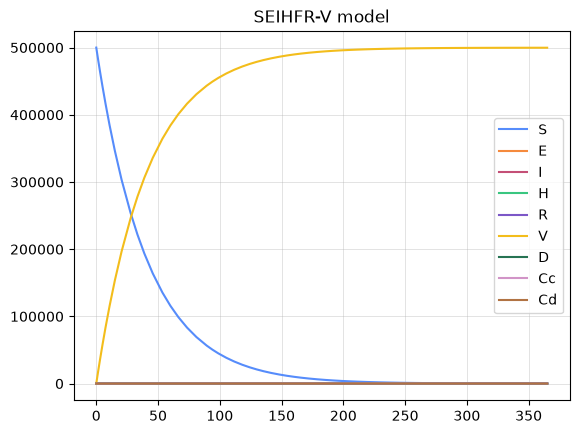

In [7]:
params_aggr = {**base_params, 'nu': 0.025, 'fH': 0.80, 'theta': 0.10, 'phiH': 0.10}

model_aggr = CM.EbolaSEIHFRV()
model_aggr(inits, trange, N, params_aggr)

print(f"R0 = {model_aggr.R0:.3f}")
print(f"Total cases: {model_aggr.traces['Cc'][-1]:,.0f}")
print(f"Total deaths: {model_aggr.traces['Cd'][-1]:,.0f}")

model_aggr.plot_traces()

## Scenario Comparison

Compare cumulative cases and deaths across all four scenarios.

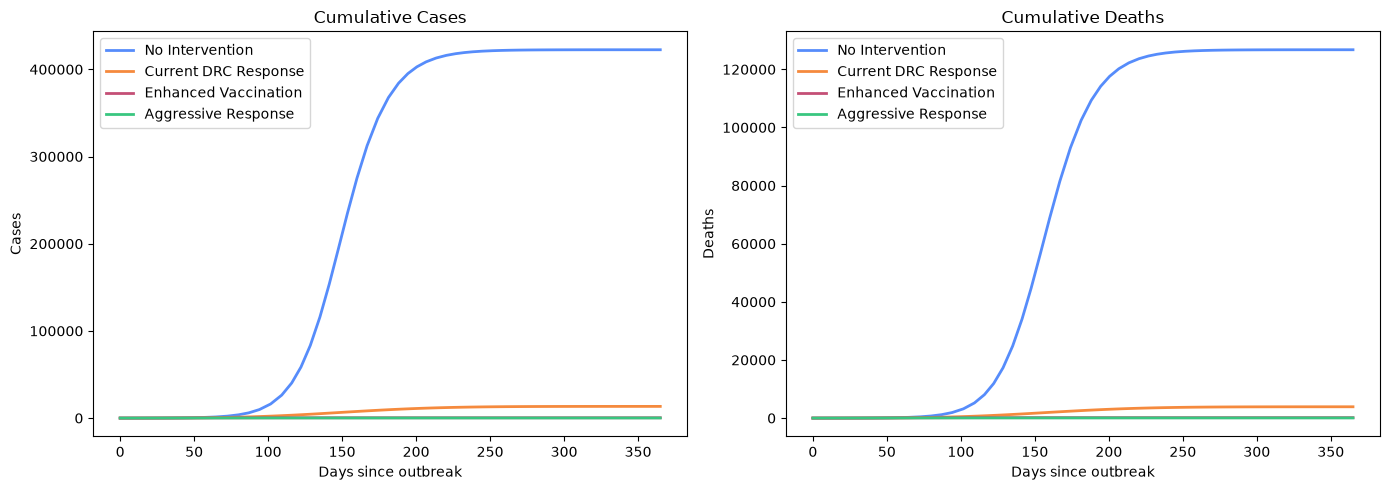

In [8]:
scenarios = {
    'No Intervention':       model_no,
    'Current DRC Response':  model_drc,
    'Enhanced Vaccination':  model_enh,
    'Aggressive Response':   model_aggr,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, mdl in scenarios.items():
    t = mdl.traces['time']
    axes[0].plot(t, mdl.traces['Cc'], label=name, linewidth=2)
    axes[1].plot(t, mdl.traces['Cd'], label=name, linewidth=2)

axes[0].set_title('Cumulative Cases')
axes[0].set_xlabel('Days since outbreak')
axes[0].set_ylabel('Cases')
axes[0].legend()

axes[1].set_title('Cumulative Deaths')
axes[1].set_xlabel('Days since outbreak')
axes[1].set_ylabel('Deaths')
axes[1].legend()

plt.tight_layout()
plt.show()

## R0 Decomposition

The basic reproduction number decomposes into community, hospital, and funeral transmission contributions.

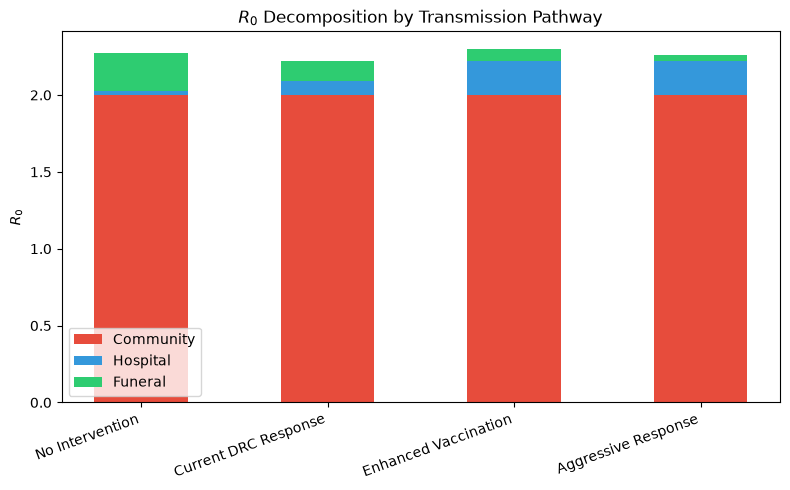

In [9]:
labels = list(scenarios.keys())
models_list = list(scenarios.values())

community = [m.R0_components['community'] for m in models_list]
hospital  = [m.R0_components['hospital']  for m in models_list]
funeral   = [m.R0_components['funeral']   for m in models_list]

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, community, width, label='Community', color='#e74c3c')
ax.bar(x, hospital,  width, bottom=community, label='Hospital', color='#3498db')
ax.bar(x, funeral,   width, bottom=np.array(community) + np.array(hospital),
       label='Funeral', color='#2ecc71')

ax.set_ylabel('$R_0$')
ax.set_title('$R_0$ Decomposition by Transmission Pathway')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

## Vaccination Timing Analysis

Each day of delay in vaccination deployment has an exponential cost in lives. Using the Enhanced Vaccination scenario ($\nu = 1.5\%$/day), we simulate outbreaks with delays of 0, 7, 14, 21, 30, 45, 60, 90, and 120 days.

In [11]:
delays = [0, 7, 14, 21, 30, 45, 60, 90, 120]
results = []

for delay in delays:
    # Two-phase simulation: pre-vaccination (nu=0) then post-vaccination (nu=0.015)
    params_pre = {**base_params, 'nu': 0.0, 'fH': 0.80, 'theta': 0.20, 'phiH': 0.10}
    params_post = {**params_pre, 'nu': 0.015}

    if delay == 0:
        mdl = CM.EbolaSEIHFRV()
        mdl(inits, [0, 365], N, params_post)
    else:
        # Phase 1: no vaccination
        mdl = CM.EbolaSEIHFRV()
        mdl(inits, [0, delay], N, params_pre)
        end_state = [mdl.traces[v][-1] for v in mdl.state_variables]
        # Phase 2: with vaccination, continue from end of phase 1
        # validate=False because cumulative compartments (Cc, Cd) make sum > N
        mdl2 = CM.EbolaSEIHFRV()
        mdl2(end_state, [delay, 365], N, params_post, validate=False)
        # Merge traces
        for v in mdl.state_variables:
            mdl.traces[v] = np.concatenate([mdl.traces[v], mdl2.traces[v]])
        mdl.traces['time'] = np.concatenate([mdl.traces['time'], mdl2.traces['time']])

    total_cases = mdl.traces['Cc'][-1]
    total_deaths = mdl.traces['Cd'][-1]
    results.append((delay, total_cases, total_deaths))
    print(f"Delay {delay:3d} days: {total_cases:>10,.0f} cases, {total_deaths:>8,.0f} deaths")

Delay   0 days:        366 cases,      147 deaths
Delay   7 days:        601 cases,      238 deaths
Delay  14 days:        969 cases,      382 deaths
Delay  21 days:      1,555 cases,      610 deaths
Delay  30 days:      2,835 cases,    1,109 deaths
Delay  45 days:      7,579 cases,    2,960 deaths
Delay  60 days:     19,482 cases,    7,602 deaths
Delay  90 days:     95,211 cases,   37,136 deaths
Delay 120 days:    243,077 cases,   94,804 deaths


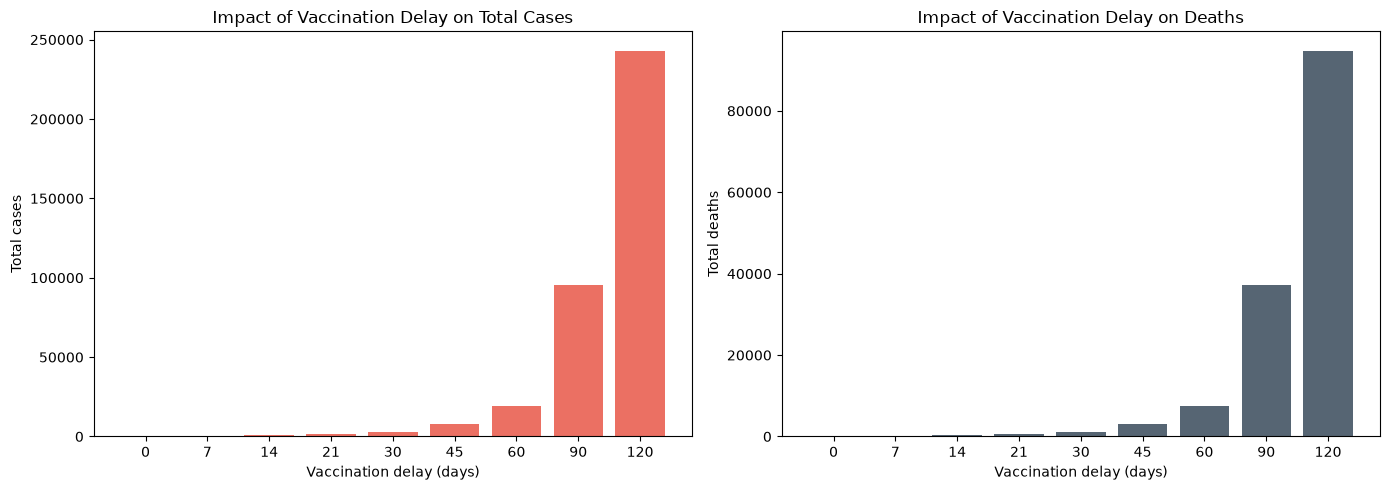

In [12]:
d = np.array([r[0] for r in results])
cases = np.array([r[1] for r in results])
deaths = np.array([r[2] for r in results])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(d.astype(str), cases, color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Vaccination delay (days)')
axes[0].set_ylabel('Total cases')
axes[0].set_title('Impact of Vaccination Delay on Total Cases')

axes[1].bar(d.astype(str), deaths, color='#2c3e50', alpha=0.8)
axes[1].set_xlabel('Vaccination delay (days)')
axes[1].set_ylabel('Total deaths')
axes[1].set_title('Impact of Vaccination Delay on Deaths')

plt.tight_layout()
plt.show()

## Key Findings

- **Speed of response is more important than scale of response.** Every day of delay in vaccination deployment has an exponential cost in lives.
- **Ring vaccination is the decisive intervention** — it rapidly reduces the susceptible pool below the epidemic threshold.
- **Funeral/burial transmission** accounts for ~7–8% of $R_0$ but is the most modifiable risk factor (safe and dignified burials).
- **Hospital IPC** reduces the importance of hospital transmission but alone cannot control the epidemic.
- The relationship between vaccination delay and deaths is **exponential**, not linear.